# Using YOLO
> Training YOLO on the COCO8 dataset


In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO

# Load a pretrained YOLO26n model
model = YOLO("yolo26n.pt")

# Train the model on the COCO8 dataset for 100 epochs
train_results = model.train(
    data="coco8.yaml",  # Path to dataset configuration file (coco128, VOC, VisDrone)
    epochs=4,  # Number of training epochs
    imgsz=640,  # Image size for training
    device="cpu",  # Device to run on (e.g., 'cpu', 0, [0,1,2,3])
    plots=True
)

# Evaluate the model's performance on the validation set
metrics = model.val()

In [9]:
from IPython.display import Image, display

# Standard YOLO Metrics

- `train/box_loss & val/box_loss`: Bounding-box localization error. The model found the object, but the predicted box may be too large, too small, or misaligned.

- `train/cls_loss & val/cls_loss`: Classification error. The model may locate an object correctly but assign it the wrong class.

- `train/dfl_loss`: Distribution Focal Loss, a technical measure related to how precisely the model predicts bounding-box boundaries.

- `metrics/precision(B)` (Precision): Of all detections labeled as a given class, how many were correct? Low precision means more false positives.

- `metrics/recall(B)` (Recall): Of all objects of a class in the image, how many did the model find? Low recall means more false negatives.

- `metrics/mAP50(B)` (Mean Average Precision at 50% IoU): The mean average precision when a predicted box overlaps the ground-truth box by at least 50%. Higher values indicate better detection performance.

Performance Metrics (Loss and mAP)


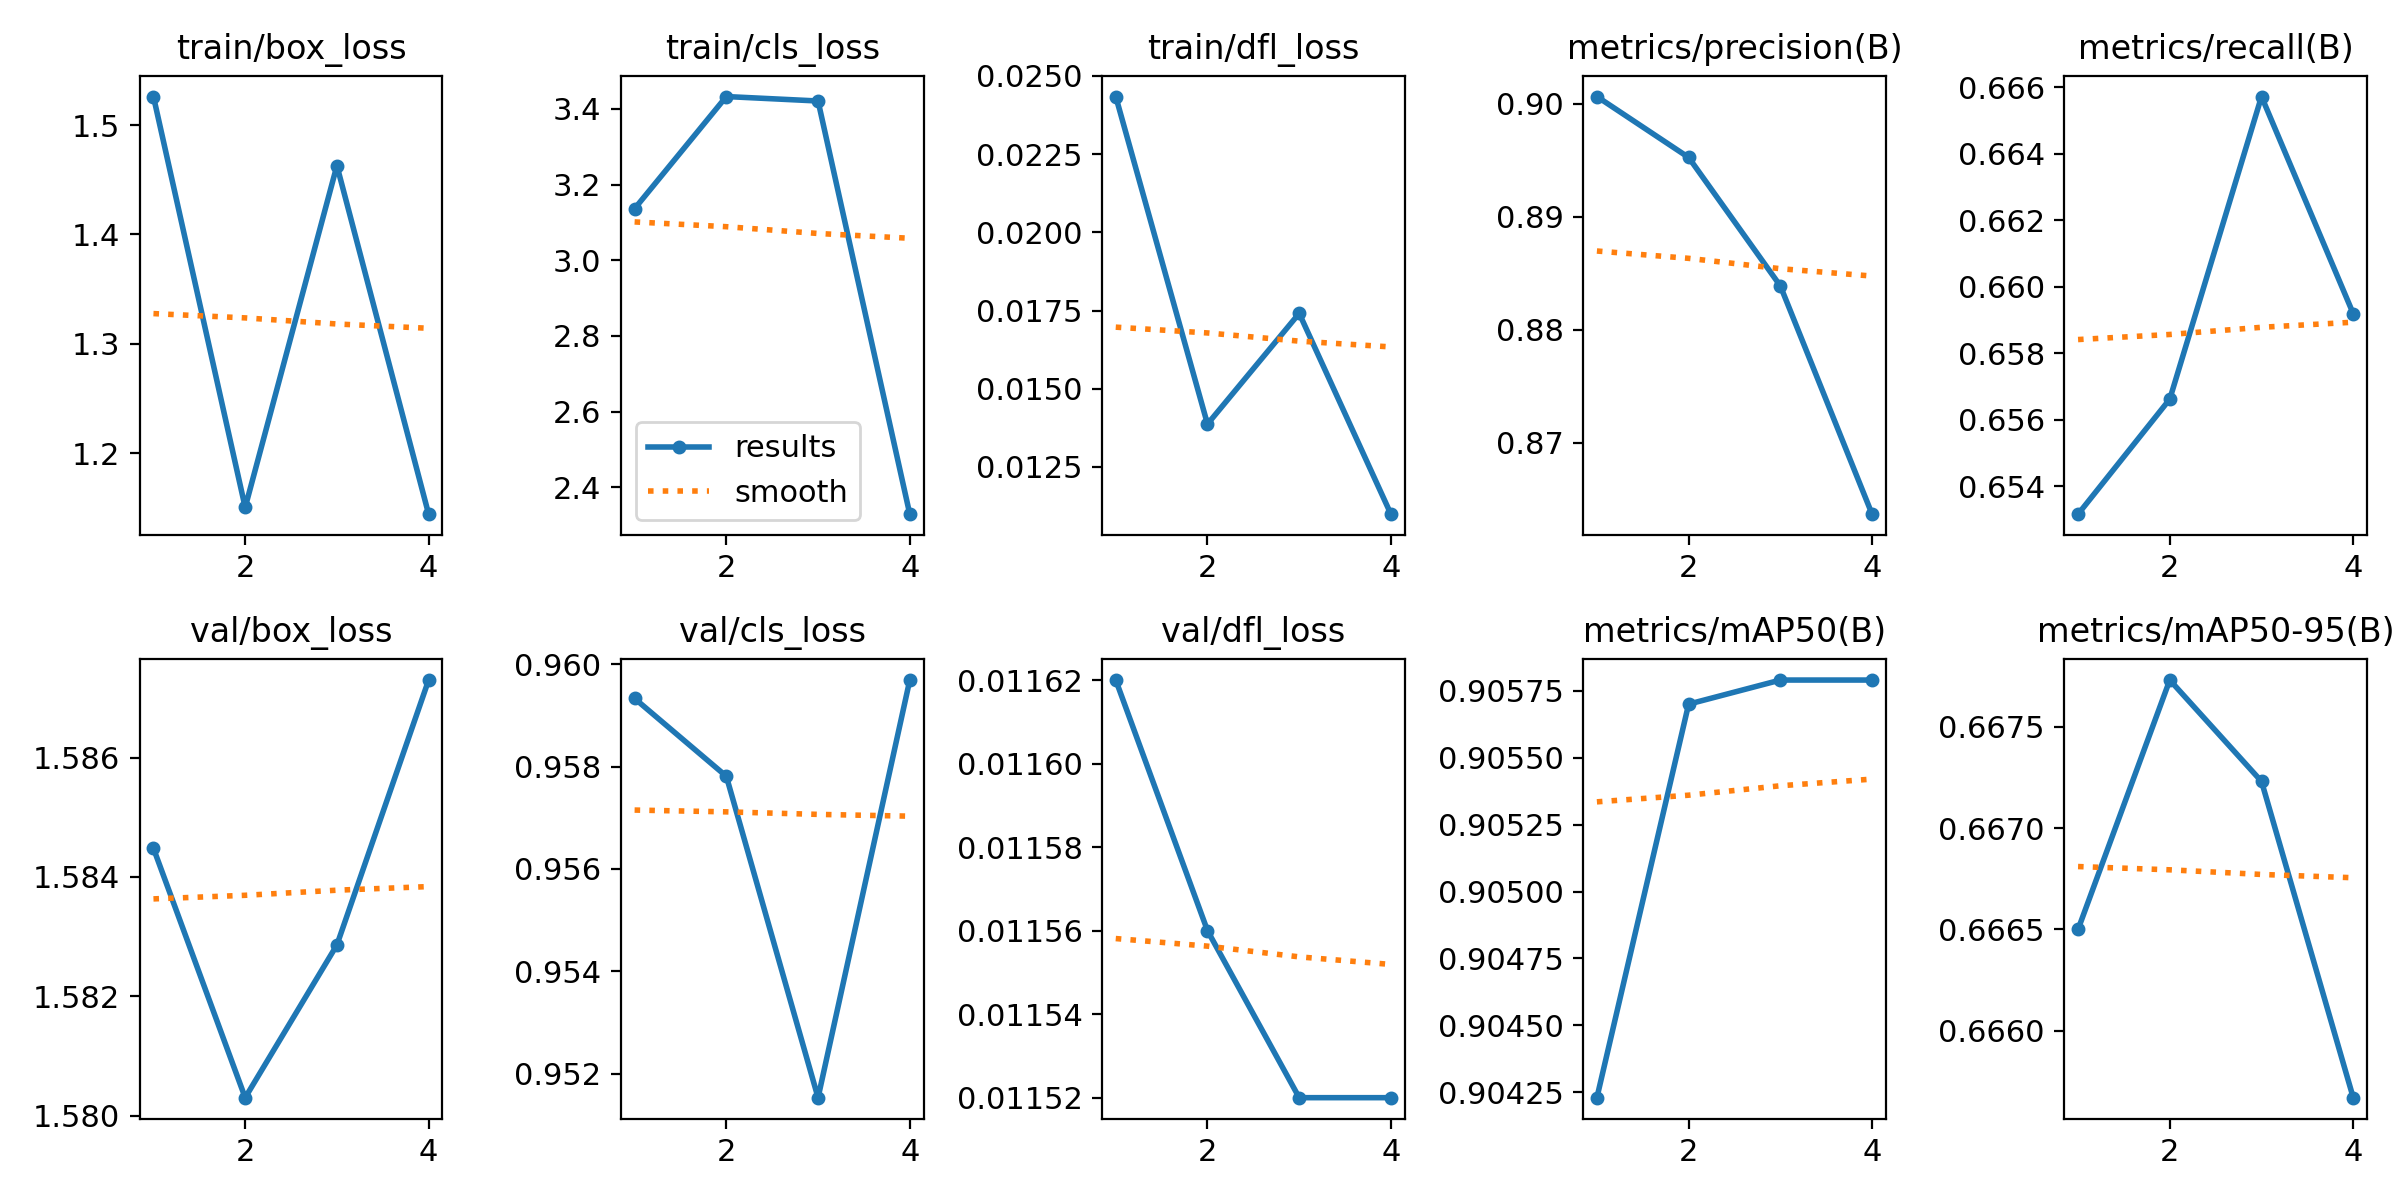

In [10]:
print("Performance Metrics (Loss and mAP)")
display(Image(filename='runs/detect/train/results.png', width=1000))

# Confusion Matrix
Analyzing TP, FP, FN, and TN

Confusion Matrix


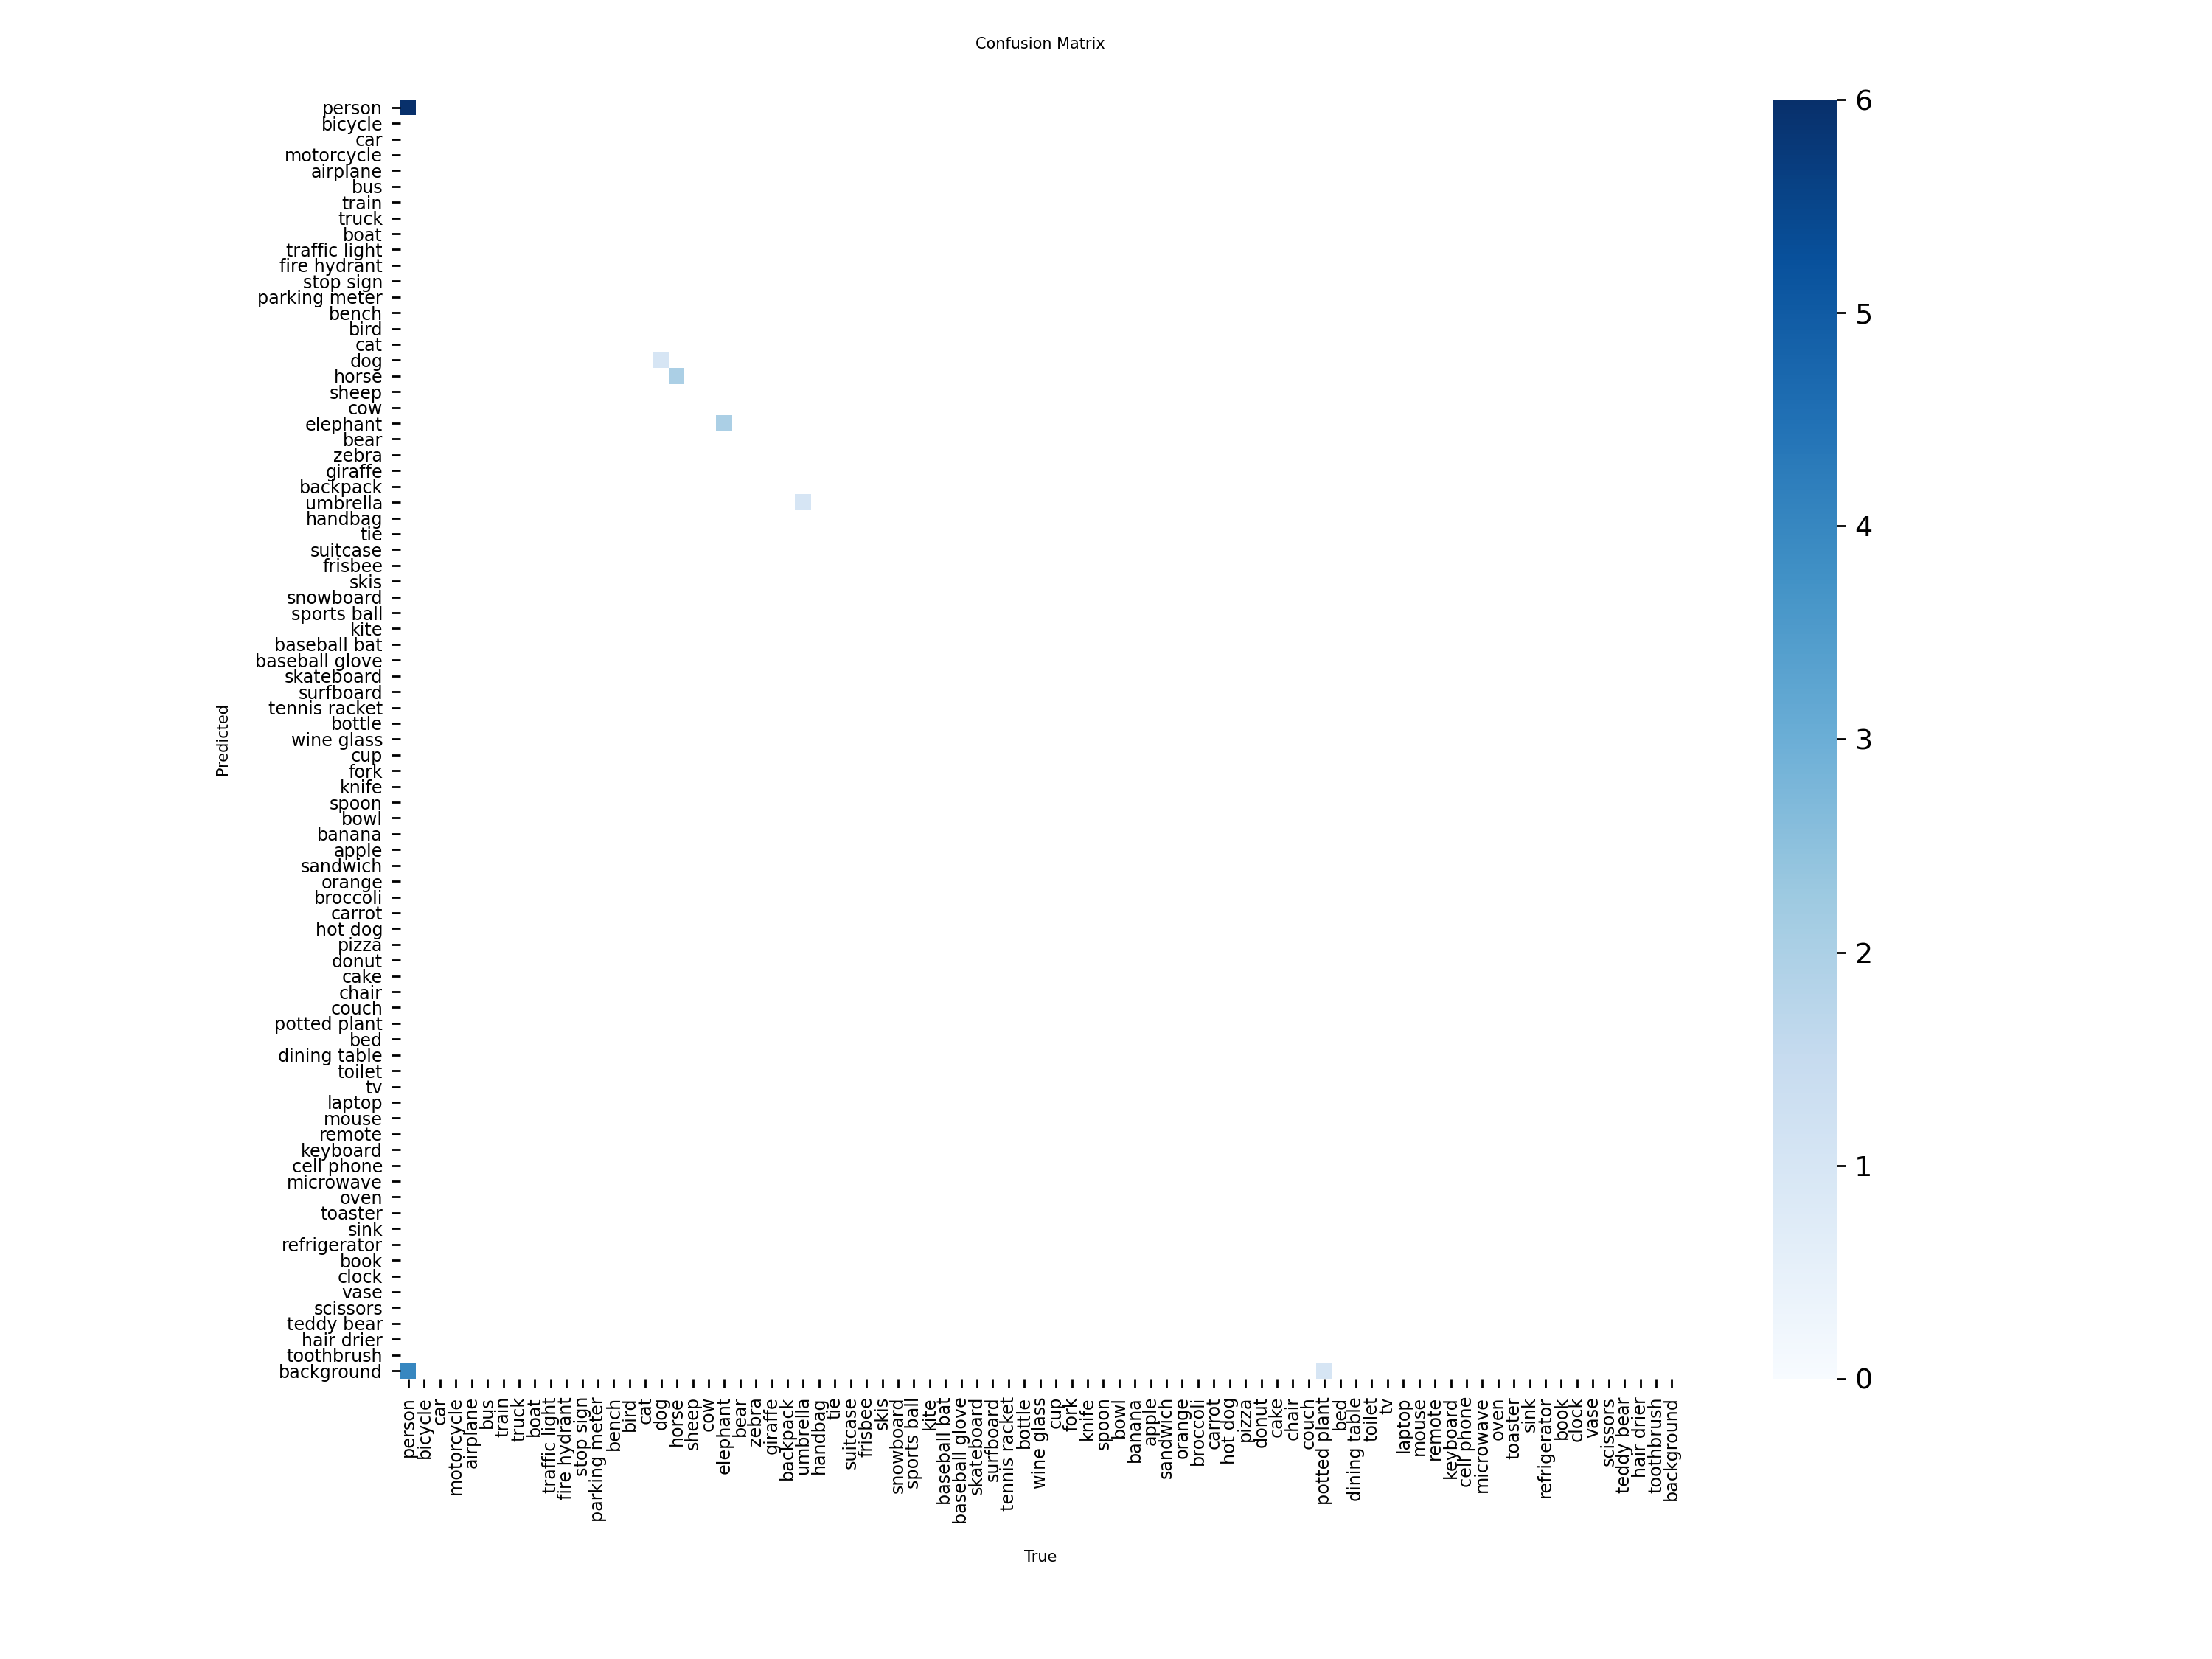

In [7]:
print("Confusion Matrix")
display(Image(filename='runs/detect/train/confusion_matrix.png', width=800))

# F1 Score

The F1 score indicates whether your model has reached a good balance between false positives and false negatives. In the BoxF1_curve plot, the peak shows the confidence threshold to use for the best balance.

F1 Score Curve


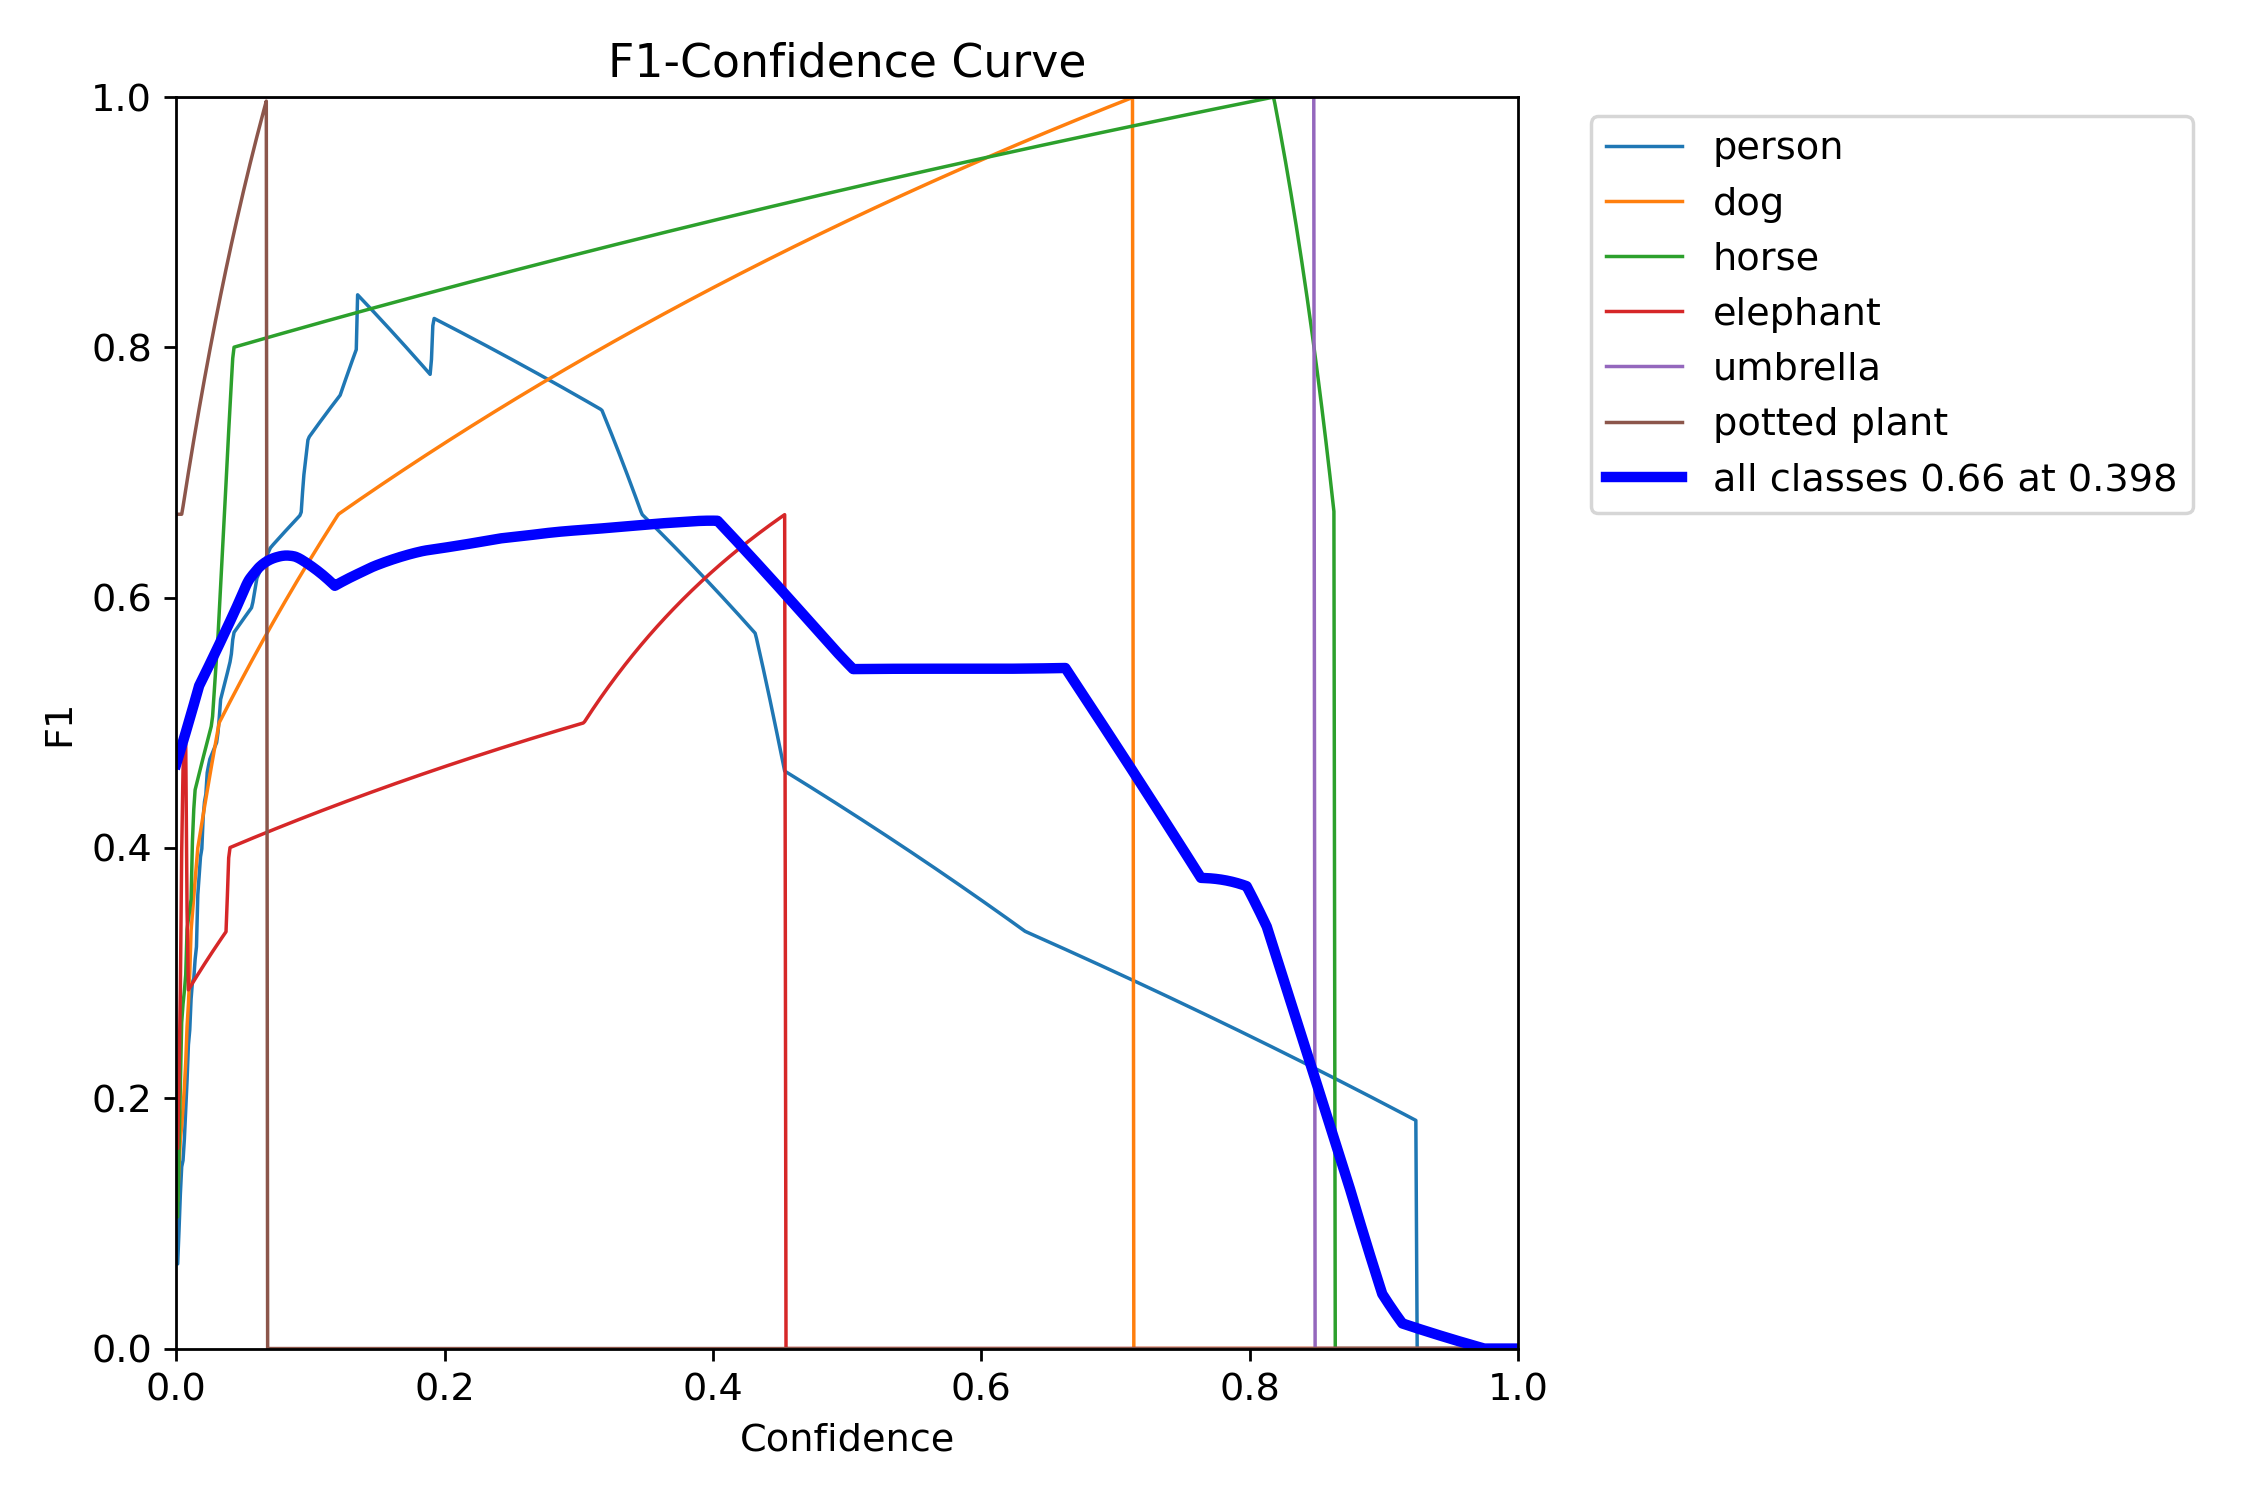

In [9]:
print("F1 Score Curve")
display(Image(filename='runs/detect/train/BoxF1_curve.png', width=800))